#### 1. Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#### 2. Custom function to generate synthetic data

In [2]:
def generate_data(n_samples, mu, noise_std=0.1):
    """
    Generate synthetic training and testing data.
    Training data: N(0, 1)
    Testing data: N(mu, 1)
    """
    X_train = np.random.normal(0, 1, n_samples)
    X_test = np.random.normal(mu, 1, n_samples)

    # Define linear relationship with noise
    Y_train = 2 * X_train + np.random.normal(0, noise_std, n_samples)
    Y_test = 2 * X_test + np.random.normal(0, noise_std, n_samples)

    return X_train.reshape(-1, 1), Y_train, X_test.reshape(-1, 1), Y_test

#### 3. Kernel Ridge Regression with SGD

In [3]:
def kernel_ridge_sgd(X, y, kernel, alpha, learning_rate, max_iter):
    """
    Kernel Ridge Regression using Stochastic Gradient Descent.
    """
    n_samples = X.shape[0]

    # Initialize dual coefficients
    alpha_vals = np.zeros(n_samples)

    # Precompute kernel matrix
    K = kernel(X, X)

    # SGD loop
    for iteration in range(max_iter):
        for i in range(n_samples):
            gradient = 2 * alpha * alpha_vals[i] - 2 * (y[i] - np.dot(K[i], alpha_vals))
            alpha_vals[i] -= learning_rate * gradient

    return alpha_vals

#### 4. Defining Kernel

In [4]:
def rbf_kernel(X1, X2, gamma=1.0):
    """Radial Basis Function (RBF) kernel."""
    pairwise_sq_dists = np.sum(X1**2, axis=1).reshape(-1, 1) + np.sum(X2**2, axis=1) - 2 * np.dot(X1, X2.T)
    return np.exp(-gamma * pairwise_sq_dists)

#### 5. Calculate MSE and R^2

In [5]:
def calculate_metrics(y_true, y_pred):
    """
    Calculate Mean Squared Error (MSE) and R^2 score.
    """
    mse = np.mean((y_true - y_pred)**2)
    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)
    return mse, r2

#### 6. Main Experiment Setup

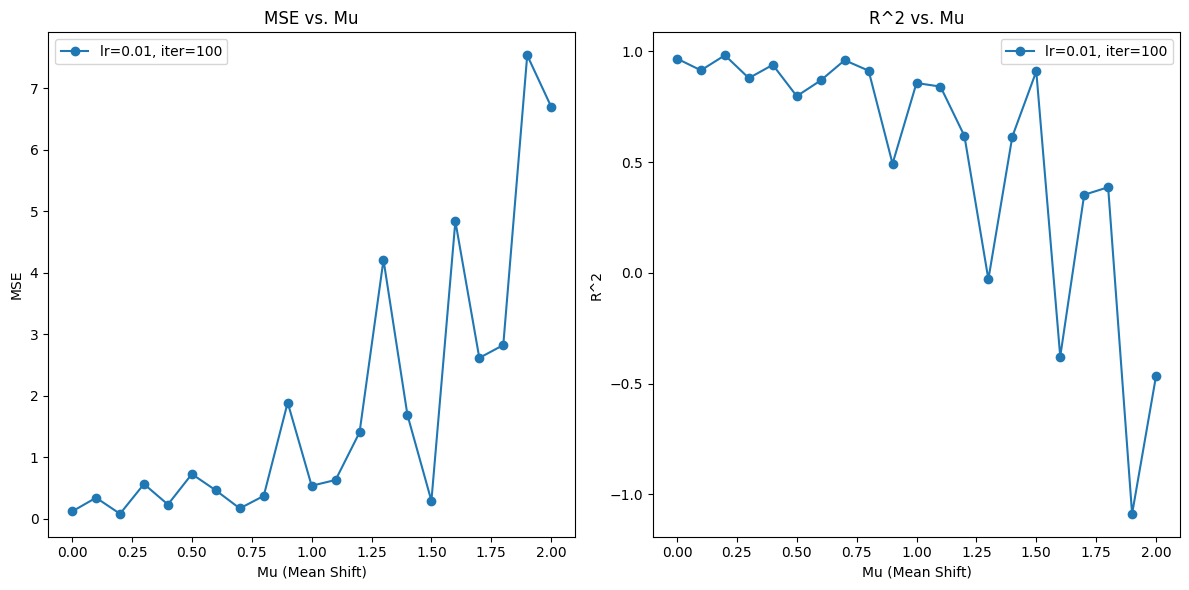

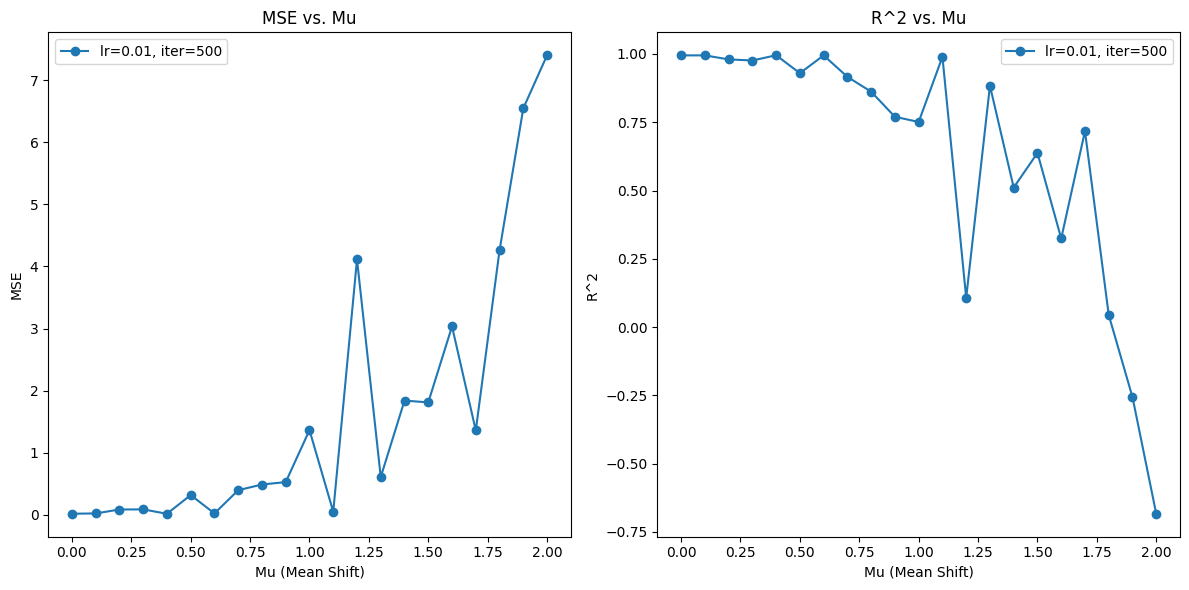

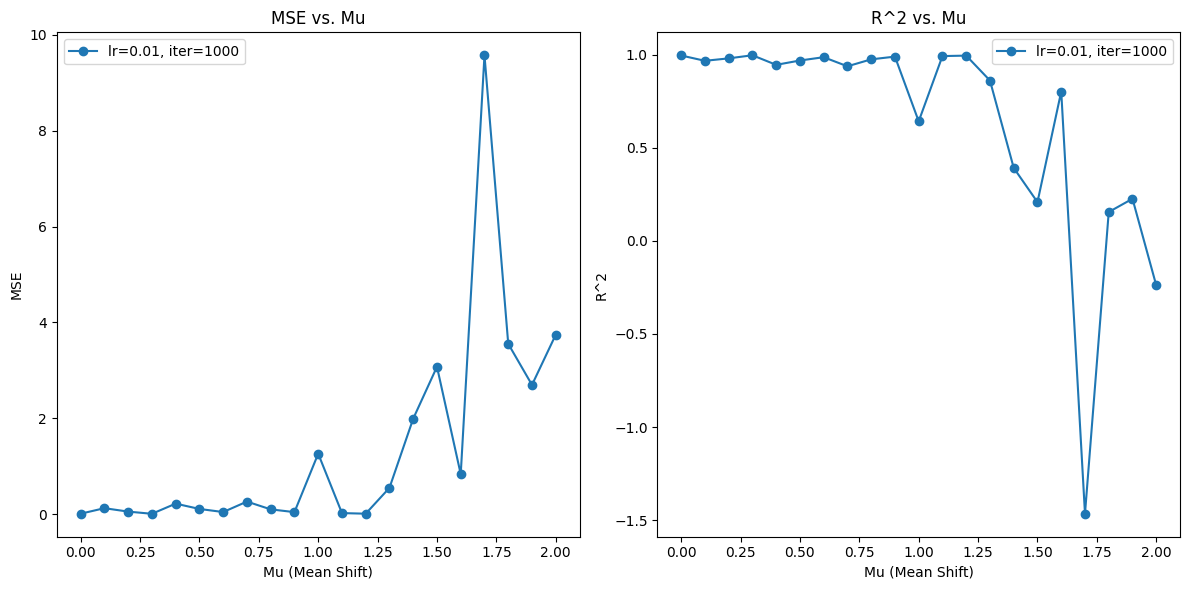

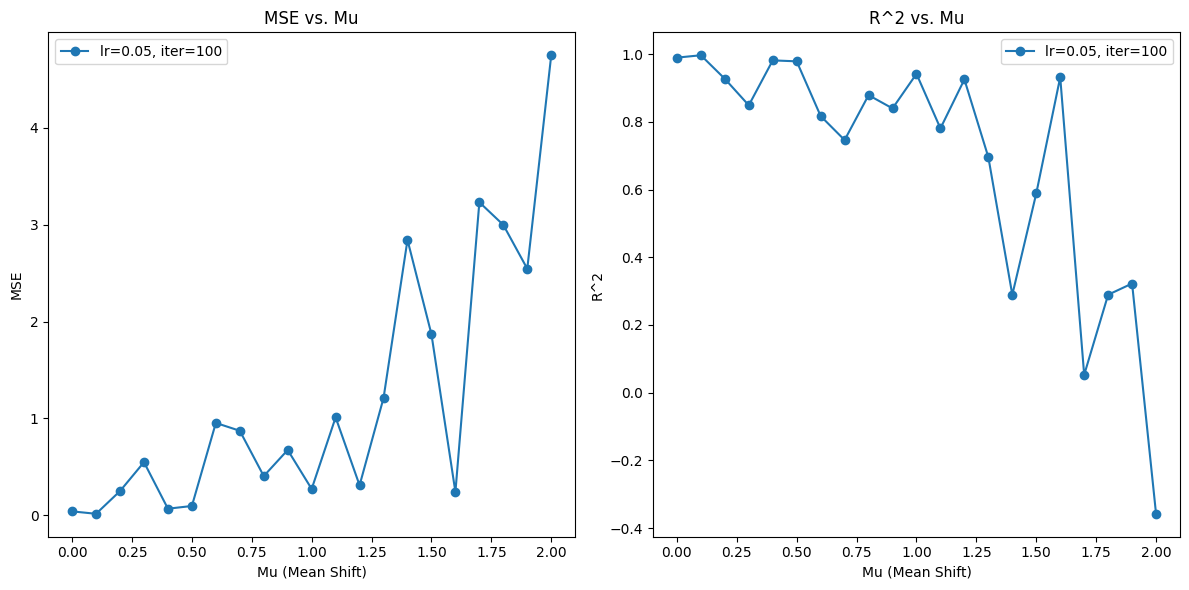

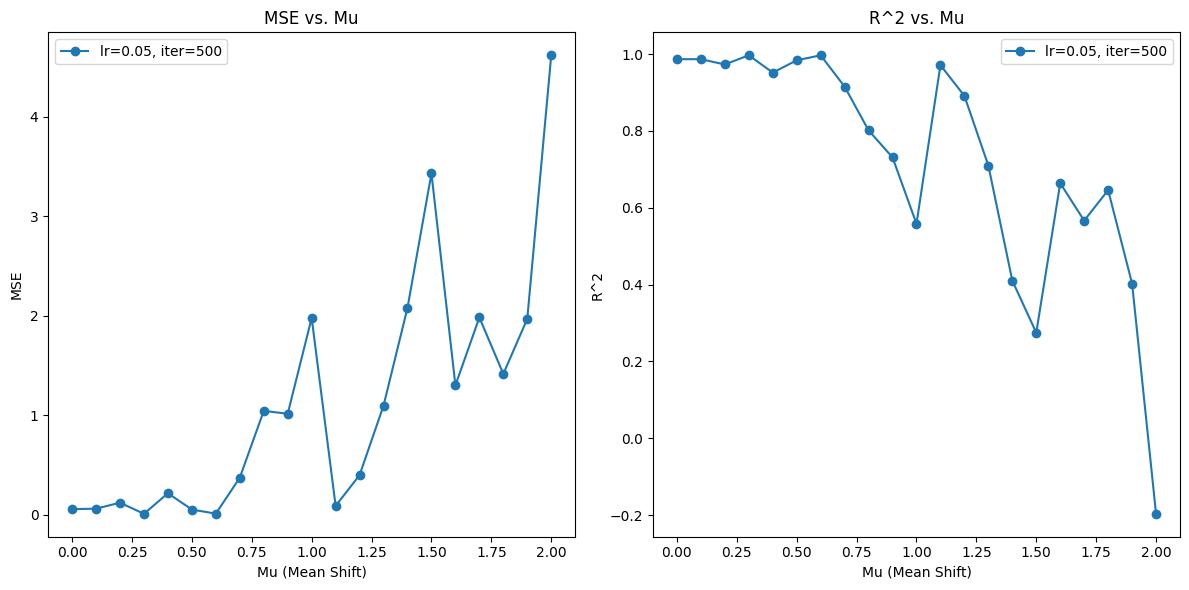

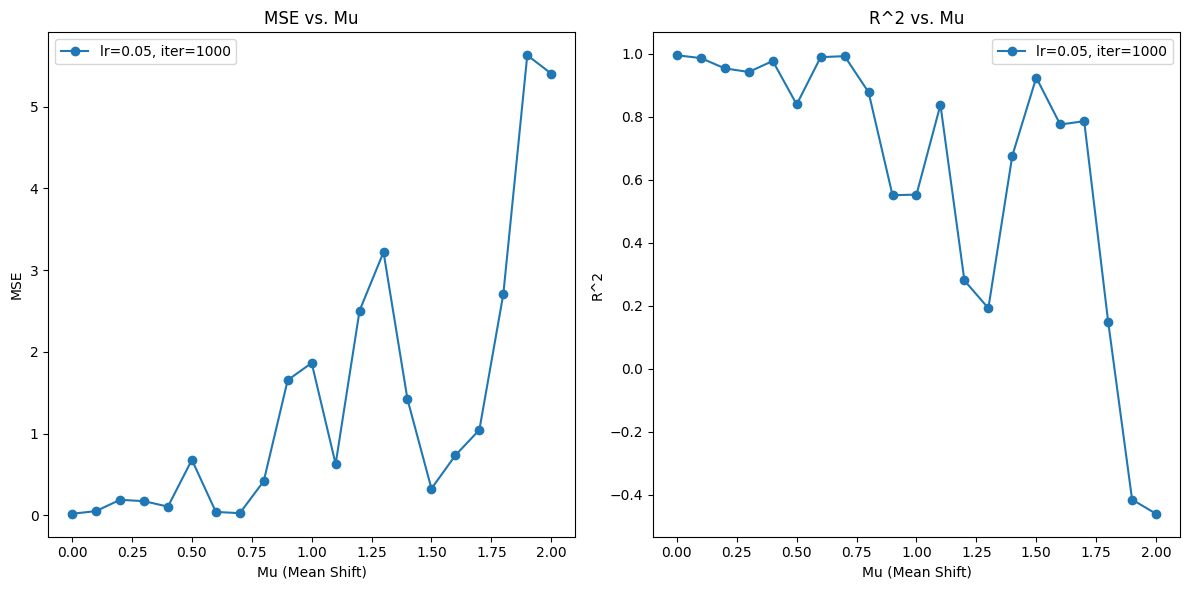

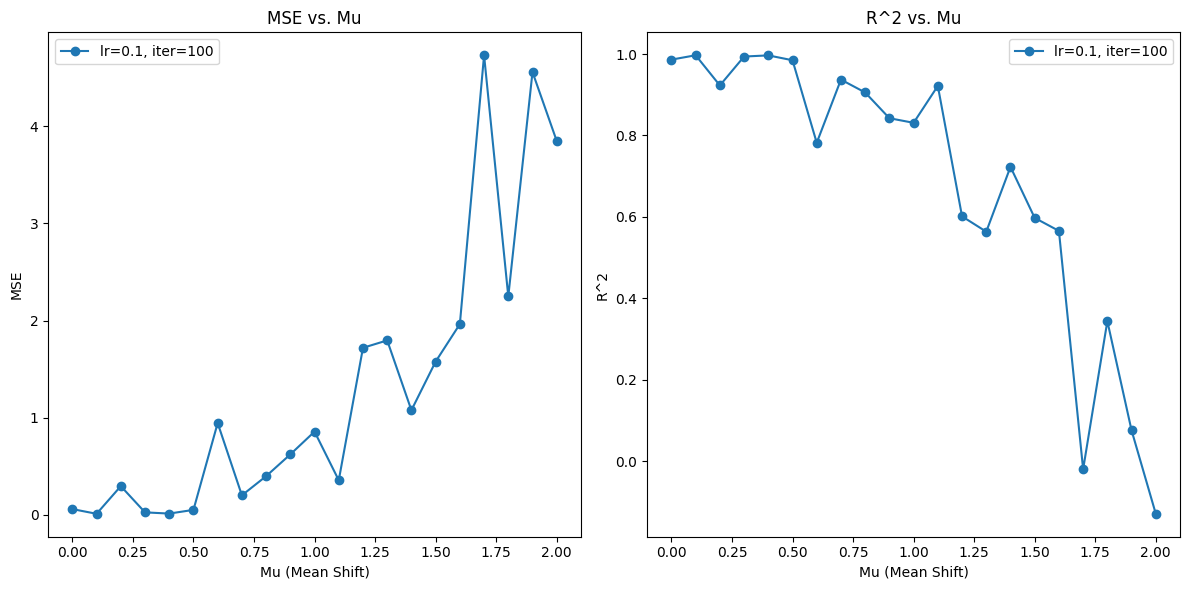

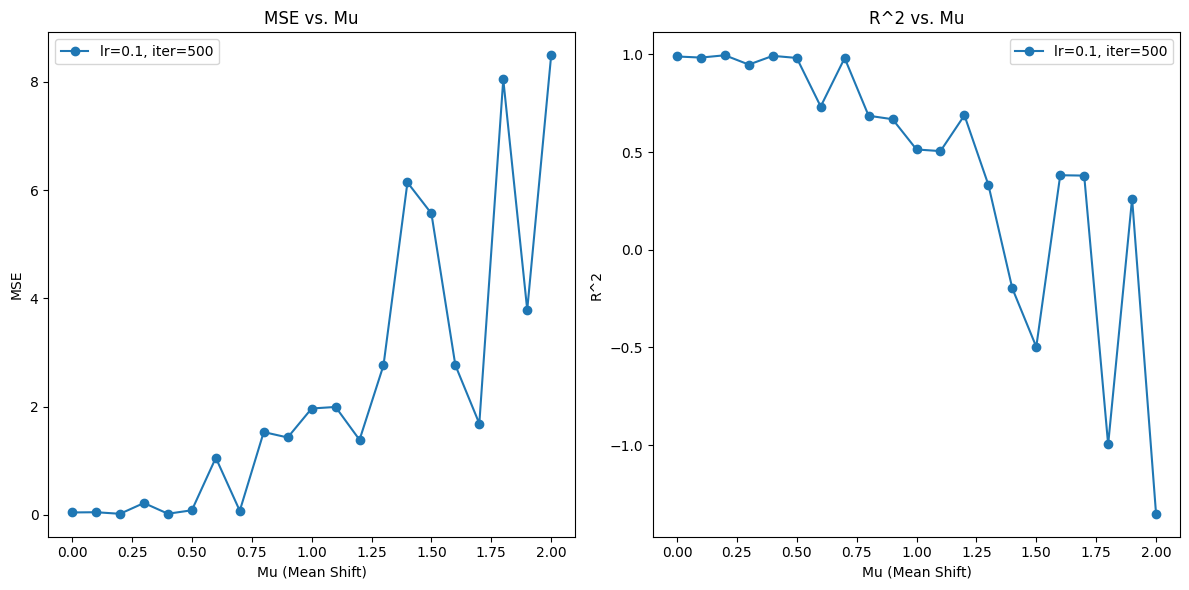

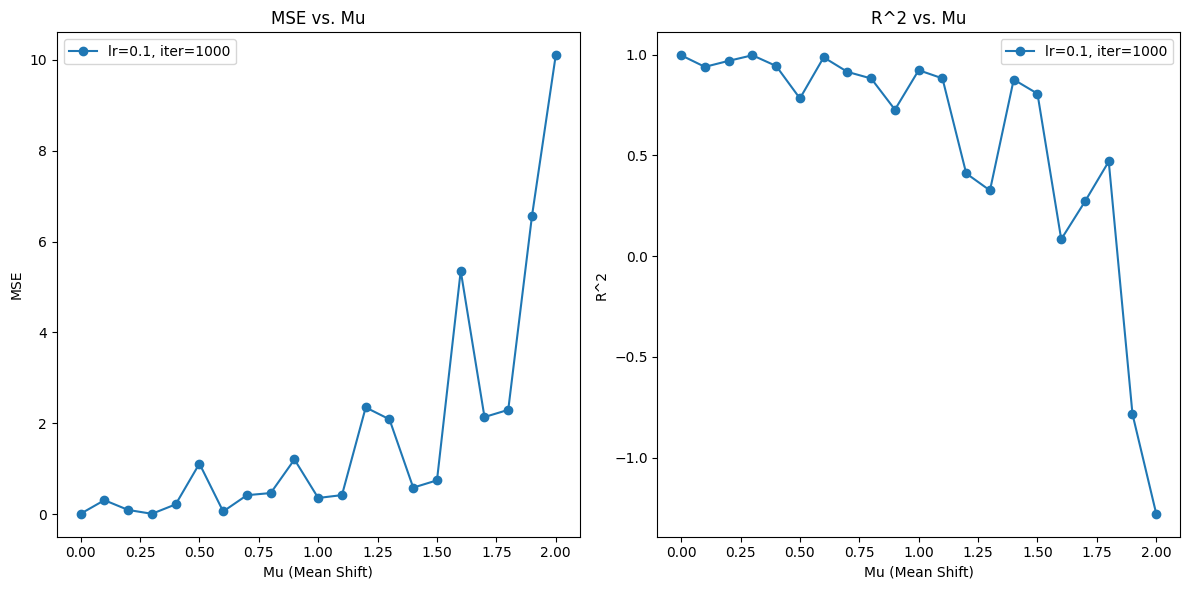

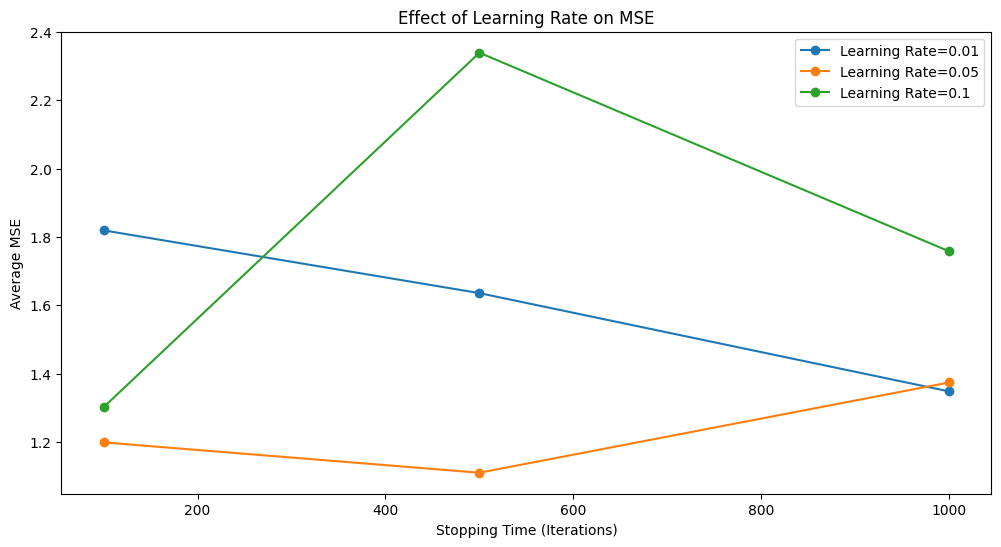

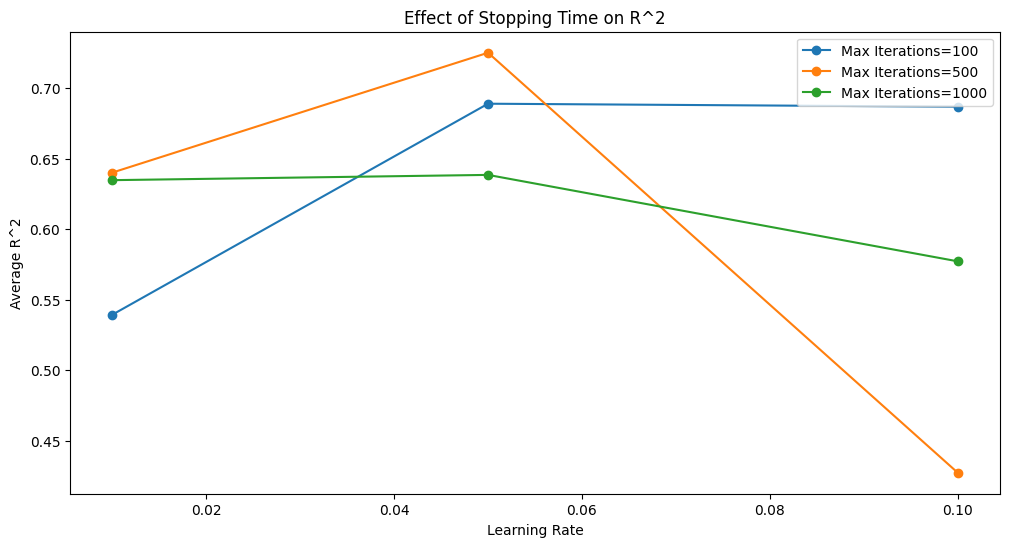

In [7]:
n_samples = 100
mus = np.linspace(0, 2, 21)
learning_rate_grid = [0.01, 0.05, 0.1]
max_iter_grid = [100, 500, 1000]
alpha = 0.1

gamma = 0.5  # Parameter for RBF kernel

results = []

for learning_rate in learning_rate_grid:
    for max_iter in max_iter_grid:
        mses = []
        r2s = []

        for mu in mus:
            # Generate data
            X_train, Y_train, X_test, Y_test = generate_data(n_samples, mu)

            # Train model
            alpha_vals = kernel_ridge_sgd(X_train, Y_train, rbf_kernel, alpha, learning_rate, max_iter)

            # Predict on test data
            K_test = rbf_kernel(X_test, X_train)
            Y_pred = np.dot(K_test, alpha_vals)

            # Evaluate
            mse, r2 = calculate_metrics(Y_test, Y_pred)
            mses.append(mse)
            r2s.append(r2)

        results.append({
            'learning_rate': learning_rate,
            'max_iter': max_iter,
            'mus': mus,
            'mses': mses,
            'r2s': r2s
        })

        # Plot MSE and R^2 for different mu
        plt.figure(figsize=(12, 6))

        plt.subplot(1, 2, 1)
        plt.plot(mus, mses, marker='o', label=f'lr={learning_rate}, iter={max_iter}')
        plt.title('MSE vs. Mu')
        plt.xlabel('Mu (Mean Shift)')
        plt.ylabel('MSE')
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(mus, r2s, marker='o', label=f'lr={learning_rate}, iter={max_iter}')
        plt.title('R^2 vs. Mu')
        plt.xlabel('Mu (Mean Shift)')
        plt.ylabel('R^2')
        plt.legend()

        plt.tight_layout()
        plt.show()

# Analyze the effect of learning rate and stopping time further
plt.figure(figsize=(12, 6))

# Effect of learning rate on MSE
for learning_rate in learning_rate_grid:
    avg_mses = []
    for result in results:
        if result['learning_rate'] == learning_rate:
            avg_mses.append(np.mean(result['mses']))
    plt.plot(max_iter_grid, avg_mses, marker='o', label=f'Learning Rate={learning_rate}')

plt.title('Effect of Learning Rate on MSE')
plt.xlabel('Stopping Time (Iterations)')
plt.ylabel('Average MSE')
plt.legend()
plt.show()

# Effect of stopping time on R^2
plt.figure(figsize=(12, 6))

for max_iter in max_iter_grid:
    avg_r2s = []
    for result in results:
        if result['max_iter'] == max_iter:
            avg_r2s.append(np.mean(result['r2s']))
    plt.plot(learning_rate_grid, avg_r2s, marker='o', label=f'Max Iterations={max_iter}')

plt.title('Effect of Stopping Time on R^2')
plt.xlabel('Learning Rate')
plt.ylabel('Average R^2')
plt.legend()
plt.show()